# Model 

In [1]:
# ============================================================
# CELL 1: INSTALL + IMPORTS
# ============================================================


import numpy as np
import torch
import torch.nn as nn
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
import matplotlib.pyplot as plt
import time


## Loading dataset and splitting


In [3]:
# ============================================================
# CELL 2: LOAD DATASET
# ============================================================
dataset_dict = torch.load("../data/pyg_dataset.pt", weights_only=False)

train_dataset = dataset_dict["train_dataset"]
val_dataset = dataset_dict["val_dataset"]
test_dataset = dataset_dict["test_dataset"]
train_cases = dataset_dict["train_cases"]
val_cases = dataset_dict["val_cases"]
test_cases = dataset_dict["test_cases"]

print(f"Train: {len(train_dataset)} graphs — cases {train_cases}")
print(f"Val:   {len(val_dataset)} graphs — cases {val_cases}")
print(f"Test:  {len(test_dataset)} graphs — cases {test_cases}")

# Inspect one graph
sample = train_dataset[0]
print(f"\nSample graph:")
print(f"  Node features (x):    {sample.x.shape}   → {sample.x.shape[1]} features per node")
print(f"  Edge index:            {sample.edge_index.shape}")
print(f"  Edge features:         {sample.edge_attr.shape} → {sample.edge_attr.shape[1]} features per edge")
print(f"  Targets (y):           {sample.y.shape}   → {sample.y.shape[1]} targets per node")
print(f"  Case: {sample.case.item()}, T_inlet={sample.T_inlet.item():.1f}K, "
      f"ṁ={sample.mass_flow.item():.3f}, T_out={sample.T_outdoor.item():.1f}K")

Train: 45 graphs — cases [2, 3, 4, 5, 8, 10, 13, 15, 16, 17, 19, 21, 22, 23, 25, 26, 27, 28, 30, 31, 33, 34, 35, 36, 37, 38, 39, 41, 43, 44, 45, 46, 47, 49, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 65]
Val:   9 graphs — cases [11, 14, 18, 29, 32, 40, 42, 63, 64]
Test:  10 graphs — cases [1, 7, 9, 12, 20, 24, 48, 50, 51, 55]

Sample graph:
  Node features (x):    torch.Size([73841, 12])   → 12 features per node
  Edge index:            torch.Size([2, 645268])
  Edge features:         torch.Size([645268, 4]) → 4 features per edge
  Targets (y):           torch.Size([73841, 5])   → 5 targets per node
  Case: 61, T_inlet=290.6K, ṁ=0.746, T_out=311.4K


## Compute Normalization Stats

In [4]:
# ============================================================
# CELL 3: NORMALIZATION STATS (training set only)
# ============================================================
all_x = torch.stack([d.x for d in train_dataset])      # (39, 73841, 12)
all_y = torch.stack([d.y for d in train_dataset])      # (39, 73841, 5)
edge_attr = train_dataset[0].edge_attr                  # (645268, 4)

# Node features
x_mean = all_x.reshape(-1, 12).mean(dim=0)
x_std  = all_x.reshape(-1, 12).std(dim=0)
x_std[x_std < 1e-8] = 1.0   # constant features get std=1 to avoid division by zero

# Targets
y_mean = all_y.reshape(-1, 5).mean(dim=0)
y_std  = all_y.reshape(-1, 5).std(dim=0)

# Edge features
e_mean = edge_attr.mean(dim=0)
e_std  = edge_attr.std(dim=0)
e_std[e_std < 1e-8] = 1.0

# Print everything
feature_names = ["x", "y", "z",
                 "interior", "people", "desk", "computer", "outside_wall", "wall",
                 "T_inlet", "mass_flow", "T_outdoor"]
target_names = ["T", "U", "V", "W", "G"]
edge_names = ["dx", "dy", "dz", "dist"]

print("NODE FEATURE STATS:")
print(f"  {'Feature':<15s}  {'Mean':>10s}  {'Std':>10s}")
print(f"  {'-'*15}  {'-'*10}  {'-'*10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<15s}  {x_mean[i]:>10.4f}  {x_std[i]:>10.4f}")

print(f"\nTARGET STATS:")
print(f"  {'Target':<5s}  {'Mean':>10s}  {'Std':>10s}")
print(f"  {'-'*5}  {'-'*10}  {'-'*10}")
for i, name in enumerate(target_names):
    print(f"  {name:<5s}  {y_mean[i]:>10.4f}  {y_std[i]:>10.4f}")

print(f"\nEDGE FEATURE STATS:")
print(f"  {'Edge':<5s}  {'Mean':>10s}  {'Std':>10s}")
print(f"  {'-'*5}  {'-'*10}  {'-'*10}")
for i, name in enumerate(edge_names):
    print(f"  {name:<5s}  {e_mean[i]:>10.6f}  {e_std[i]:>10.6f}")

norm_stats = {
    "x_mean": x_mean, "x_std": x_std,
    "y_mean": y_mean, "y_std": y_std,
    "e_mean": e_mean, "e_std": e_std,
}

del all_x, all_y
print("\n✅ Normalization stats computed")

NODE FEATURE STATS:
  Feature                Mean         Std
  ---------------  ----------  ----------
  x                    2.8277      0.2208
  y                    0.6099      0.3440
  z                   -0.9732      0.1055
  interior             0.8917      0.3107
  people               0.0855      0.2796
  desk                 0.0186      0.1351
  computer             0.0000      0.0037
  outside_wall         0.0000      1.0000
  wall                 0.0042      0.0648
  T_inlet            297.2189      6.0051
  mass_flow            0.4720      0.2595
  T_outdoor          296.1256     10.7455

TARGET STATS:
  Target        Mean         Std
  -----  ----------  ----------
  T        299.6641      4.8250
  U         -0.0614      0.0842
  V         -0.0039      0.0376
  W         -0.0062      0.0489
  G       1930.8118     78.7638

EDGE FEATURE STATS:
  Edge         Mean         Std
  -----  ----------  ----------
  dx       0.000000    0.009548
  dy      -0.000000    0.010390
  d

## Architecture

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
  GPU: NVIDIA GeForce RTX 3060 Laptop GPU
  VRAM: 6.4 GB


In [6]:
# ============================================================
# CELL 4: MESHGRAPHNET MODEL
# ============================================================

class MLP(nn.Module):
    """2-hidden-layer MLP with ReLU + optional LayerNorm"""
    def __init__(self, input_dim, output_dim, hidden_dim=128, layer_norm=True):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
        self.layer_norm = nn.LayerNorm(output_dim) if layer_norm else None

    def forward(self, x):
        x = self.net(x)
        if self.layer_norm is not None:
            x = self.layer_norm(x)
        return x


class ProcessorBlock(MessagePassing):
    """
    One round of message passing with gradient checkpointing + mixed precision.
    """
    def __init__(self, hidden_dim=128):
        super().__init__(aggr="sum")
        self.edge_mlp = MLP(3 * hidden_dim, hidden_dim, hidden_dim, layer_norm=True)
        self.node_mlp = MLP(2 * hidden_dim, hidden_dim, hidden_dim, layer_norm=True)

    def _edge_update(self, edge_input):
        return self.edge_mlp(edge_input)

    def _node_update(self, node_input):
        return self.node_mlp(node_input)

    def forward(self, x, edge_index, edge_attr):
        row, col = edge_index
        edge_input = torch.cat([edge_attr, x[row], x[col]], dim=-1)

        edge_attr = edge_attr + torch.utils.checkpoint.checkpoint(
            self._edge_update, edge_input, use_reentrant=False
        )

        node_update = self.propagate(edge_index, edge_attr=edge_attr)
        node_input = torch.cat([x, node_update], dim=-1)

        x = x + torch.utils.checkpoint.checkpoint(
            self._node_update, node_input, use_reentrant=False
        )

        return x, edge_attr

    def message(self, edge_attr):
        return edge_attr

class MeshGraphNet(nn.Module):
    """
    Full Encode-Process-Decode MeshGraphNet

    Encoder:   12 node features → 128,  4 edge features → 128
    Processor: 15 rounds of message passing with residual connections
    Decoder:   128 → 5 targets (T, U, V, W, G)
    """
    def __init__(self, node_in=12, edge_in=4, target_out=5,
                 hidden_dim=128, num_layers=15, norm_stats=None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        if norm_stats is None:
            raise ValueError("norm_stats required")

        # Store normalization stats as buffers (move to GPU with model)
        self.register_buffer("x_mean", norm_stats["x_mean"])
        self.register_buffer("x_std", norm_stats["x_std"])
        self.register_buffer("y_mean", norm_stats["y_mean"])
        self.register_buffer("y_std", norm_stats["y_std"])
        self.register_buffer("e_mean", norm_stats["e_mean"])
        self.register_buffer("e_std", norm_stats["e_std"])

        # Encoder
        self.node_encoder = MLP(node_in, hidden_dim, hidden_dim, layer_norm=True)
        self.edge_encoder = MLP(edge_in, hidden_dim, hidden_dim, layer_norm=True)

        # Processor: 15 separate blocks, each with own weights
        self.processor_blocks = nn.ModuleList([
            ProcessorBlock(hidden_dim) for _ in range(num_layers)
        ])

        # Decoder (no LayerNorm — outputs physical values)
        self.decoder = MLP(hidden_dim, target_out, hidden_dim, layer_norm=False)

    def forward(self, data):
      x = data.x
      edge_index = data.edge_index
      edge_attr = data.edge_attr

      # Normalize inputs
      x = (x - self.x_mean) / self.x_std
      edge_attr = (edge_attr - self.e_mean) / self.e_std

      # Encode
      x = self.node_encoder(x)
      edge_attr = self.edge_encoder(edge_attr)

      # Process
      for block in self.processor_blocks:
          x, edge_attr = block(x, edge_index, edge_attr)

      # Decode (normalized output)
      pred_norm = self.decoder(x)

      # Denormalize for evaluation
      pred_phys = pred_norm * self.y_std + self.y_mean

      return pred_norm, pred_phys


# Build the model
model = MeshGraphNet(
    node_in=12,
    edge_in=4,
    target_out=5,
    hidden_dim=128,
    num_layers=10,
    norm_stats=norm_stats,
).to(device)
# Add this after model = MeshGraphNet(...).to(device)


n_params = sum(p.numel() for p in model.parameters())
print(f"Model: MeshGraphNet")
print(f"  Hidden dim:      128")
print(f"  Processor layers: 10")
print(f"  Parameters:      {n_params:,}")
print(f"  Device:          {device}")

Model: MeshGraphNet
  Hidden dim:      128
  Processor layers: 10
  Parameters:      1,589,893
  Device:          cuda


## Plots and Evaluations

### Loading the Model

In [16]:
import os
import torch

# ── Model path (folder you gave + the trial-2 filename) ──────
MODEL_PATH = "model.pt"

assert os.path.exists(MODEL_PATH), f"NOT FOUND:\n{MODEL_PATH}"
print(f"File found ({os.path.getsize(MODEL_PATH)/1e6:.1f} MB)")
# ── 2. Architecture must already be instantiated ────────────
try:
    model
except NameError:
    raise NameError("`model` is not defined. Run the model-definition cell first, "
                    "then this script. load_state_dict needs the architecture in memory.")

# ── 3. Load weights and check key match ─────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
state = torch.load(MODEL_PATH, map_location=device, weights_only=False)

missing, unexpected = model.load_state_dict(state, strict=False)
if missing or unexpected:
    print(f"WARNING missing keys ({len(missing)}): {missing[:5]}")
    print(f"WARNING unexpected keys ({len(unexpected)}): {unexpected[:5]}")
    print("Architecture in memory does NOT fully match the saved model.")
else:
    print("All weight keys matched (architecture is consistent)")

model.eval().to(device)
if hasattr(model, "y_mean"):
    print(f"Normalization buffer y_mean loaded: {model.y_mean.flatten().tolist()}")

# ── 4. Sanity forward pass on a real sample ─────────────────
ds = torch.load("../data/pyg_dataset.pt", weights_only=False)

sample = ds["test_dataset"][0].to(device)
with torch.no_grad():
    _, pred = model(sample)

print(f"\nForward pass OK, output shape {tuple(pred.shape)}")
print(f"  NaNs: {torch.isnan(pred).sum().item()}   Infs: {torch.isinf(pred).sum().item()}")

names = ["T (degC)", "U (m/s)", "V (m/s)", "W (m/s)", "G (W/m2)"]
for i, nm in enumerate(names):
    col = pred[:, i]
    lo, hi = col.min().item(), col.max().item()
    if i == 0:                     # temperature: K -> C
        lo, hi = lo - 273.15, hi - 273.15
    print(f"  {nm:<10} range [{lo:>8.3f}, {hi:>8.3f}]  std {col.std().item():.4f}")

File found (6.4 MB)
All weight keys matched (architecture is consistent)
Normalization buffer y_mean loaded: [299.6640625, -0.06140948459506035, -0.0038544991984963417, -0.006218264810740948, 1930.811767578125]

Forward pass OK, output shape (73841, 5)
  NaNs: 0   Infs: 0
  T (degC)   range [  29.799,   33.531]  std 0.5488
  U (m/s)    range [  -0.138,    0.043]  std 0.0421
  V (m/s)    range [  -0.068,    0.049]  std 0.0189
  W (m/s)    range [  -0.108,    0.169]  std 0.0272
  G (W/m2)   range [1922.949, 2057.011]  std 22.0294


### Test Set Evaluation

In [17]:
# ============================================================
# TEST SET EVALUATION
# Recreates the reported test metrics from the trained model.
# Run after the dataset cell and the model-definition cell.
# ============================================================
import torch
from torch_geometric.loader import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Load weights into the already-defined architecture ──────
state = torch.load(MODEL_PATH, map_location=device, weights_only=False)
model.load_state_dict(state)
model.eval().to(device)
print(f"Loaded {MODEL_PATH}")

# ── Test loader (test_dataset comes from the dataset cell) ──
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# ── Run inference over the test set ─────────────────────────
all_preds, all_targets = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        _, pred_phys = model(batch)
        all_preds.append(pred_phys.cpu())
        all_targets.append(batch.y.cpu())

all_preds = torch.cat(all_preds, dim=0)
all_targets = torch.cat(all_targets, dim=0)

# ── Metrics ─────────────────────────────────────────────────
target_names = ["T (K)", "U (m/s)", "V (m/s)", "W (m/s)", "G (W/m²)"]

print("\n" + "=" * 64)
print(f"TEST SET EVALUATION ({len(test_dataset)} unseen cases)")
print("=" * 64)
print(f"\n  {'Target':<12s}  {'RMSE':>10s}  {'MAE':>10s}  {'NMAE':>10s}  {'R²':>10s}")
print(f"  {'-'*12}  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*10}")

for i, name in enumerate(target_names):
    true_i, pred_i = all_targets[:, i], all_preds[:, i]
    rmse = torch.sqrt(torch.mean((pred_i - true_i) ** 2)).item()
    mae  = torch.mean(torch.abs(pred_i - true_i)).item()
    std  = true_i.std().item()
    nmae = mae / std if std > 1e-8 else float("nan")
    r2   = 1 - (rmse / std) ** 2 if std > 1e-8 else float("nan")
    print(f"  {name:<12s}  {rmse:>10.4f}  {mae:>10.4f}  {nmae:>10.4f}  {r2:>10.4f}")

# Velocity magnitude
Vmag_true = torch.sqrt(all_targets[:, 1]**2 + all_targets[:, 2]**2 + all_targets[:, 3]**2)
Vmag_pred = torch.sqrt(all_preds[:, 1]**2 + all_preds[:, 2]**2 + all_preds[:, 3]**2)
rmse = torch.sqrt(torch.mean((Vmag_pred - Vmag_true) ** 2)).item()
mae  = torch.mean(torch.abs(Vmag_pred - Vmag_true)).item()
std  = Vmag_true.std().item()
nmae = mae / std if std > 1e-8 else float("nan")
r2   = 1 - (rmse / std) ** 2 if std > 1e-8 else float("nan")
print(f"  {'|V| (m/s)':<12s}  {rmse:>10.4f}  {mae:>10.4f}  {nmae:>10.4f}  {r2:>10.4f}")

Loaded model.pt

TEST SET EVALUATION (10 unseen cases)

  Target              RMSE         MAE        NMAE          R²
  ------------  ----------  ----------  ----------  ----------
  T (K)             0.7682      0.5438      0.1560      0.9514
  U (m/s)           0.0336      0.0148      0.1477      0.8881
  V (m/s)           0.0151      0.0076      0.1680      0.8889
  W (m/s)           0.0182      0.0094      0.1639      0.9000
  G (W/m²)         11.2795      7.8624      0.1289      0.9658
  |V| (m/s)         0.0392      0.0195      0.2063      0.8285


### Best and Worst Case Plots

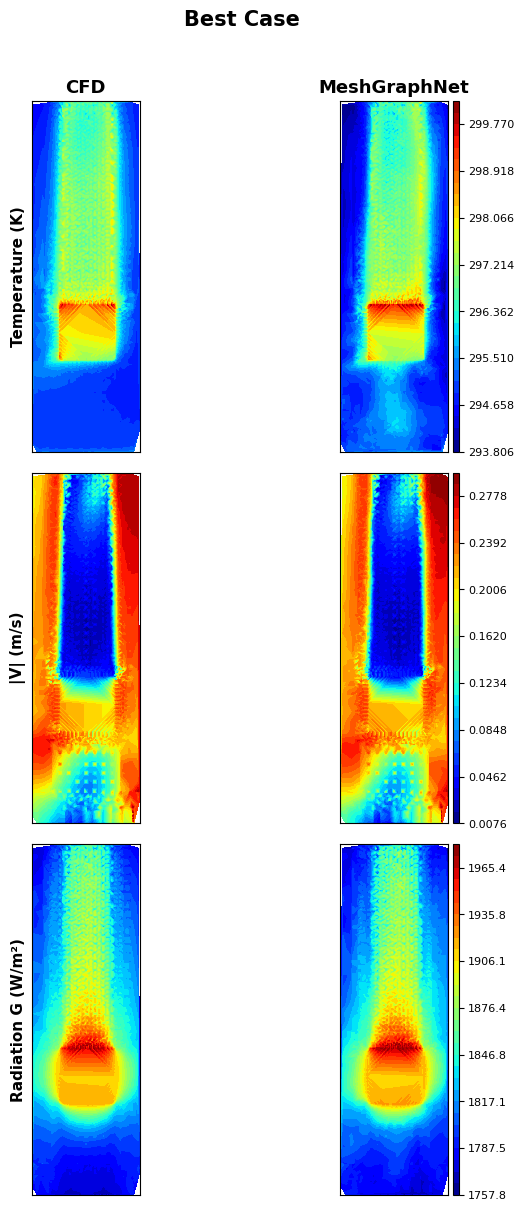

Saved: crosssection_best.png


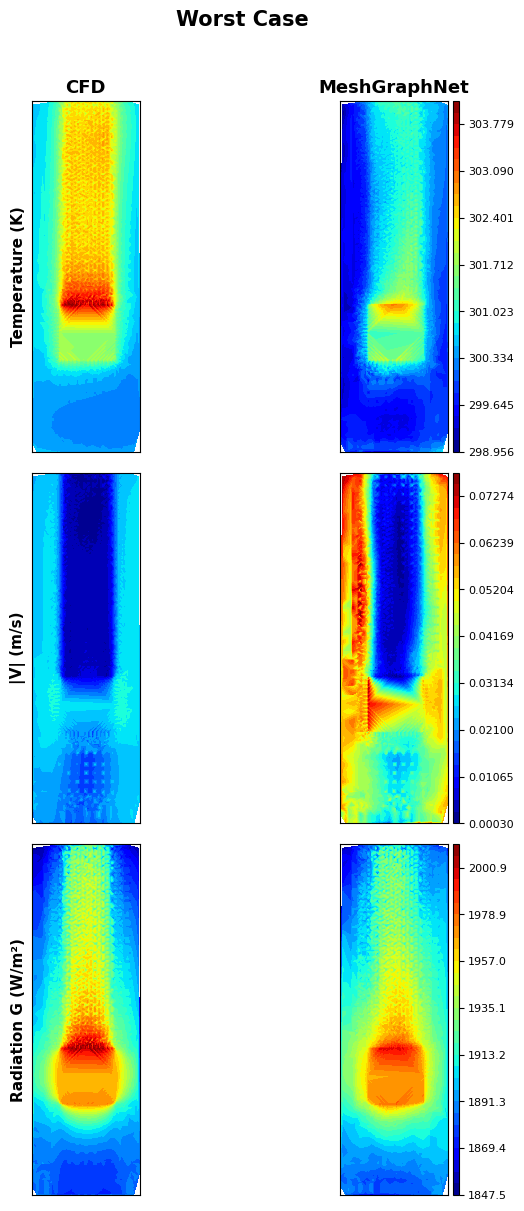

Saved: crosssection_worst.png


In [13]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from scipy.spatial import Delaunay
from mpl_toolkits.axes_grid1 import make_axes_locatable

try:
    model
except NameError:
    raise NameError("Run the model-definition cell and the load-check script first.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_SLICE, TOL = 2.80, 0.05

ds = torch.load("../data/pyg_dataset.pt", weights_only=False)
by_case = {int(d.case.item()): d for d in ds["test_dataset"]}
model.eval().to(device)

CASES = {"Best Case": 24, "Worst Case": 55}   # labels only; numbers never shown

FIELDS = [
    ("Temperature (K)",         lambda a: a[:, 0]),
    ("|V| (m/s)",               lambda a: np.sqrt(a[:,1]**2 + a[:,2]**2 + a[:,3]**2)),
    ("Radiation G (W/m\u00b2)", lambda a: a[:, 4]),
]

def predict(case):
    d = by_case[case].to(device)
    with torch.no_grad():
        _, pred = model(d)
    return d.x[:, :3].cpu().numpy(), d.y.cpu().numpy(), pred.cpu().numpy()

def plot_case(title, case):
    coords, yt, yp = predict(case)
    m = np.abs(coords[:, 0] - X_SLICE) < TOL
    z, y = coords[m, 2], coords[m, 1]
    try:
        tri = Triangulation(z, y, Delaunay(np.column_stack([z, y])).simplices)
    except Exception:
        tri = Triangulation(z, y)

    fig, axes = plt.subplots(len(FIELDS), 2, figsize=(8.5, 12.5))
    for r, (fname, fextract) in enumerate(FIELDS):
        vt, vp = fextract(yt[m]), fextract(yp[m])
        vmin, vmax = min(vt.min(), vp.min()), max(vt.max(), vp.max())
        if vmax - vmin < 1e-9:
            vmax = vmin + 1e-9
        levels = np.linspace(vmin, vmax, 31)               # shared CFD/GNN scale

        axes[r, 0].tricontourf(tri, vt, levels=levels, cmap="jet")
        im = axes[r, 1].tricontourf(tri, vp, levels=levels, cmap="jet")

        cb = fig.colorbar(im, cax=make_axes_locatable(axes[r, 1]).append_axes("right", size="5%", pad=0.05))
        cb.ax.tick_params(labelsize=8)

        axes[r, 0].set_ylabel(fname, fontsize=11, fontweight="bold")
        for ax in axes[r]:
            ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])

    axes[0, 0].set_title("CFD", fontsize=13, fontweight="bold")
    axes[0, 1].set_title("MeshGraphNet", fontsize=13, fontweight="bold")
    fig.suptitle(title, fontsize=15, fontweight="bold", y=0.965)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    out = f"crosssection_{title.split()[0].lower()}.png"
    fig.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

for title, case in CASES.items():
    plot_case(title, case)
